EXERCICE 1 : Métriques de performance — Régression et Classification
=====================================================================
Objectif : Calculer, comparer et interpréter les métriques de performance
sur un problème de fréquence sinistre (régression) et un problème de 
détection de fraude (classification).

Ce que vous allez apprendre :
- Calculer MSE, MAE, Poisson deviance et R² pour la régression
- Construire et interpréter une matrice de confusion
- Calculer precision, recall, F1 et AUC-ROC pour la classification
- Comprendre l'impact du seuil de décision sur les métriques
- Utiliser make_scorer pour des métriques custom

Pré-requis : M03_F01, M03_F05
Temps estimé : 15 minutes

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import PoissonRegressor, LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, mean_poisson_deviance,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, make_scorer
)
import matplotlib.pyplot as plt

## PARTIE 1 : MÉTRIQUES DE RÉGRESSION (Fréquence sinistre)

In [3]:
# =============================================================
# PARTIE 1 : MÉTRIQUES DE RÉGRESSION (Fréquence sinistre)
# =============================================================
print("=" * 60)
print("PARTIE 1 : Métriques de régression — Fréquence sinistre")
print("=" * 60)

df = pd.read_csv("../M03_F01_Machine_Learning_Fondamentaux/freMTPL2freq.csv")
features = ['DrivAge', 'BonusMalus', 'VehAge', 'Density']
X = df[features].astype(float)
y = df['ClaimNb'].astype(float)
exposure = df['Exposure'].astype(float)

X_train, X_test, y_train, y_test, exp_train, exp_test = train_test_split(
    X, y, exposure, test_size=0.3, random_state=42
)

freq_train = y_train / exp_train
freq_test = y_test / exp_test

# Entraîner un GLM Poisson
glm = PoissonRegressor(alpha=10e-6, max_iter=1000)
glm.fit(X_train, y_train, sample_weight=exp_train)
freq_pred = np.clip(glm.predict(X_test) / exp_test, 1e-6, None)

# TODO : Calculer les métriques de régression suivantes :
# 1. MSE (Mean Squared Error)
# 2. RMSE (Root Mean Squared Error)
# 3. MAE (Mean Absolute Error)
# 4. R² (coefficient de détermination)
# 5. Poisson Deviance (mean_poisson_deviance)

# Indice : utiliser les fonctions de sklearn.metrics
mse = mean_squared_error(freq_test, freq_pred, sample_weight=exp_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(freq_test, freq_pred, sample_weight=exp_test)
r2 = r2_score(freq_test, freq_pred, sample_weight=exp_test)
poisson_dev = mean_poisson_deviance(freq_test, freq_pred, sample_weight=exp_test)

print(f"\n{'Métrique':<25} {'Valeur':<15} {'Interprétation'}")
print("-" * 70)
print(f"{'MSE':<25} {mse:<15.6f} {'Erreur quadratique moyenne'}")
print(f"{'RMSE':<25} {rmse:<15.6f} {'En unité de fréquence'}")
print(f"{'MAE':<25} {mae:<15.6f} {'Moins sensible aux outliers'}")
print(f"{'R²':<25} {r2:<15.6f} {'% variance expliquée'}")
print(f"{'Poisson Deviance':<25} {poisson_dev:<15.6f} {'Adaptée aux comptages'}")

print("""
→ La Poisson Deviance est la métrique naturelle car :
  - Elle respecte la nature des données (comptages positifs)
  - Elle pénalise proportionnellement (erreur relative vs absolue)
  - Elle est cohérente avec le modèle (GLM Poisson = max vraisemblance Poisson)
  - Le R² peut être négatif et n'est pas adapté aux distributions asymétriques
""")



# TODO : Quelle métrique est la plus adaptée pour un problème de fréquence ?
# Pourquoi la Poisson deviance est-elle préférable à la MSE ici ?

PARTIE 1 : Métriques de régression — Fréquence sinistre

Métrique                  Valeur          Interprétation
----------------------------------------------------------------------
MSE                       0.586641        Erreur quadratique moyenne
RMSE                      0.765925        En unité de fréquence
MAE                       0.210382        Moins sensible aux outliers
R²                        -0.020665       % variance expliquée
Poisson Deviance          0.610372        Adaptée aux comptages

→ La Poisson Deviance est la métrique naturelle car :
  - Elle respecte la nature des données (comptages positifs)
  - Elle pénalise proportionnellement (erreur relative vs absolue)
  - Elle est cohérente avec le modèle (GLM Poisson = max vraisemblance Poisson)
  - Le R² peut être négatif et n'est pas adapté aux distributions asymétriques



c:\Users\U011513\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\sklearn\linear_model\_linear_loss.py:356: RuntimeWarning: invalid value encountered in matmul
  X_grad = X.T @ grad_pointwise


## PARTIE 2 : MÉTRIQUES DE CLASSIFICATION (Détection de fraude)


PARTIE 2 : Métriques de classification — Fraude
Taux de fraude : 3.1%

Accuracy du modèle : 0.9660
Accuracy naïve (toujours 'pas fraude') : 0.9693
→ L'accuracy est TROMPEUSE sur des données déséquilibrées !

Matrice de confusion :
                 Prédit: Non-fraude  Prédit: Fraude
  Réel: Non-fraude    1448             6
  Réel: Fraude        45               1

  TN=1448 | FP=6 | FN=45 | TP=1

Precision : 0.1429 (parmi les alertes, % de vraies fraudes)
Recall    : 0.0217 (parmi les fraudes, % détectées)
F1-score  : 0.0377 (moyenne harmonique)

AUC-ROC   : 0.5380
Gini      : 0.0759 (= 2×AUC - 1)


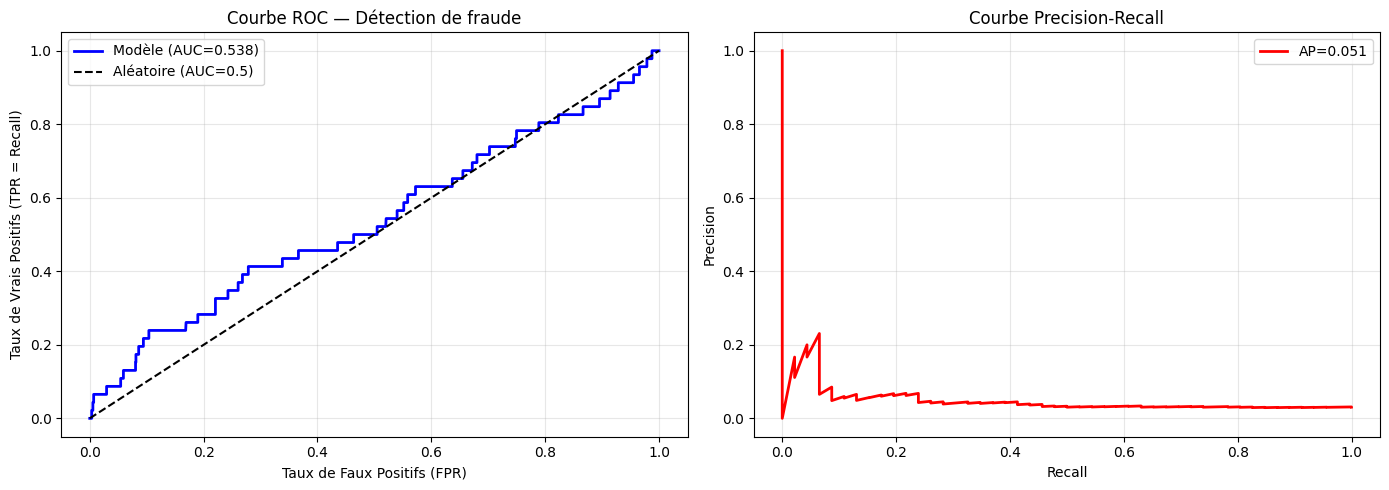

In [4]:
# =============================================================
# PARTIE 2 : MÉTRIQUES DE CLASSIFICATION (Détection de fraude)
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 2 : Métriques de classification — Fraude")
print("=" * 60)

# Simuler un dataset de fraude (déséquilibré : 3% de fraude)
np.random.seed(42)
n_claims = 5000
X_fraud = pd.DataFrame({
    'claim_amount': np.random.lognormal(7, 1.5, n_claims),
    'policy_age': np.random.uniform(0, 20, n_claims),
    'claim_delay': np.random.exponential(30, n_claims),
    'n_previous_claims': np.random.poisson(1, n_claims),
    'driver_age': np.random.normal(45, 12, n_claims).clip(18, 80),
})

# Fraude : 3% des cas, corrélée avec montant élevé et délai court
fraud_prob = 1 / (1 + np.exp(-(
    -4
    + 0.5 * (X_fraud['claim_amount'] > 5000).astype(float)
    + 0.3 * (X_fraud['claim_delay'] < 10).astype(float)
    + 0.2 * X_fraud['n_previous_claims']
    + np.random.normal(0, 0.5, n_claims)
)))
y_fraud = (np.random.random(n_claims) < fraud_prob).astype(int)
print(f"Taux de fraude : {y_fraud.mean()*100:.1f}%")

X_fr_train, X_fr_test, y_fr_train, y_fr_test = train_test_split(
    X_fraud, y_fraud, test_size=0.3, random_state=42, stratify=y_fraud
)

# Entraîner un classifieur
clf = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
clf.fit(X_fr_train, y_fr_train)

y_pred_class = clf.predict(X_fr_test)
y_pred_proba = clf.predict_proba(X_fr_test)[:, 1]

# TODO : Calculer l'accuracy. Est-elle un bon indicateur ici ?
# Indice : que vaudrait l'accuracy d'un modèle qui prédit TOUJOURS "pas de fraude" ?
# Accuracy
acc = accuracy_score(y_fr_test, y_pred_class)
acc_naive = 1 - y_fr_test.mean()  # Prédire toujours "pas fraude"
print(f"\nAccuracy du modèle : {acc:.4f}")
print(f"Accuracy naïve (toujours 'pas fraude') : {acc_naive:.4f}")
print(f"→ L'accuracy est TROMPEUSE sur des données déséquilibrées !")



# TODO : Afficher la matrice de confusion
# Indice : confusion_matrix(y_fr_test, y_pred_class)
# Identifier : True Positives, False Positives, True Negatives, False Negatives
# Matrice de confusion
cm = confusion_matrix(y_fr_test, y_pred_class)
print(f"\nMatrice de confusion :")
print(f"                 Prédit: Non-fraude  Prédit: Fraude")
print(f"  Réel: Non-fraude    {cm[0,0]:<12}     {cm[0,1]}")
print(f"  Réel: Fraude        {cm[1,0]:<12}     {cm[1,1]}")
print(f"\n  TN={cm[0,0]} | FP={cm[0,1]} | FN={cm[1,0]} | TP={cm[1,1]}")



# TODO : Calculer precision, recall et F1
# Quel est le coût d'un False Negative (fraude non détectée) ?
# Quel est le coût d'un False Positive (enquête inutile) ?
# Precision, Recall, F1
prec = precision_score(y_fr_test, y_pred_class)
rec = recall_score(y_fr_test, y_pred_class)
f1 = f1_score(y_fr_test, y_pred_class)
print(f"\nPrecision : {prec:.4f} (parmi les alertes, % de vraies fraudes)")
print(f"Recall    : {rec:.4f} (parmi les fraudes, % détectées)")
print(f"F1-score  : {f1:.4f} (moyenne harmonique)")



# TODO : Calculer l'AUC-ROC et tracer la courbe ROC
# Indice : roc_auc_score(y_fr_test, y_pred_proba)
#           fpr, tpr, thresholds = roc_curve(y_fr_test, y_pred_proba)
# AUC-ROC
auc = roc_auc_score(y_fr_test, y_pred_proba)
gini = 2 * auc - 1
print(f"\nAUC-ROC   : {auc:.4f}")
print(f"Gini      : {gini:.4f} (= 2×AUC - 1)")

# Courbe ROC
fpr, tpr, thresholds_roc = roc_curve(y_fr_test, y_pred_proba)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'Modèle (AUC={auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC=0.5)')
axes[0].set_xlabel('Taux de Faux Positifs (FPR)')
axes[0].set_ylabel('Taux de Vrais Positifs (TPR = Recall)')
axes[0].set_title('Courbe ROC — Détection de fraude')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Courbe Precision-Recall
precision_curve, recall_curve, _ = precision_recall_curve(y_fr_test, y_pred_proba)
ap = average_precision_score(y_fr_test, y_pred_proba)

axes[1].plot(recall_curve, precision_curve, 'r-', linewidth=2, label=f'AP={ap:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Courbe Precision-Recall')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=150)
plt.show()



## PARTIE 3 : IMPACT DU SEUIL DE DÉCISION

In [5]:
# =============================================================
# PARTIE 3 : IMPACT DU SEUIL DE DÉCISION
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 3 : Impact du seuil de décision")
print("=" * 60)

# TODO : Tester différents seuils (0.1, 0.2, 0.3, 0.5, 0.7)
# Pour chaque seuil, calculer precision et recall
# Tracer la courbe precision-recall
# Quel seuil choisiriez-vous pour la fraude ? (compromis coût FP vs FN)

thresholds_to_test = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7]
print(f"\n{'Seuil':<10} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Nb alertes'}")
print("-" * 55)
for t in thresholds_to_test:
    y_pred_t = (y_pred_proba >= t).astype(int)
    p = precision_score(y_fr_test, y_pred_t, zero_division=0)
    r = recall_score(y_fr_test, y_pred_t)
    f = f1_score(y_fr_test, y_pred_t, zero_division=0)
    n_alerts = y_pred_t.sum()
    print(f"{t:<10.2f} {p:<12.4f} {r:<12.4f} {f:<12.4f} {n_alerts}")

print("""
→ Seuil bas (0.05-0.1) : beaucoup d'alertes, recall élevé, precision faible
  = on détecte presque toutes les fraudes, mais beaucoup de fausses alertes
  → Adapté si le coût d'une fraude non détectée est TRÈS élevé

→ Seuil haut (0.5-0.7) : peu d'alertes, precision élevée, recall faible
  = on est sûr quand on alerte, mais on rate beaucoup de fraudes
  → Adapté si les enquêtes sont très coûteuses

→ En pratique : le seuil est choisi par le MÉTIER, pas par le data scientist
  Le DS fournit les courbes, le métier décide du compromis acceptable.
""")



PARTIE 3 : Impact du seuil de décision

Seuil      Precision    Recall       F1           Nb alertes
-------------------------------------------------------
0.05       0.0594       0.1304       0.0816       101
0.10       0.0732       0.0652       0.0690       41
0.20       0.1200       0.0652       0.0845       25
0.30       0.1579       0.0652       0.0923       19
0.50       0.1429       0.0217       0.0377       7
0.70       0.0000       0.0000       0.0000       2

→ Seuil bas (0.05-0.1) : beaucoup d'alertes, recall élevé, precision faible
  = on détecte presque toutes les fraudes, mais beaucoup de fausses alertes
  → Adapté si le coût d'une fraude non détectée est TRÈS élevé

→ Seuil haut (0.5-0.7) : peu d'alertes, precision élevée, recall faible
  = on est sûr quand on alerte, mais on rate beaucoup de fraudes
  → Adapté si les enquêtes sont très coûteuses

→ En pratique : le seuil est choisi par le MÉTIER, pas par le data scientist
  Le DS fournit les courbes, le métier décide 

## PARTIE 4 : MAKE_SCORER — MÉTRIQUE CUSTOM

In [ ]:
# =============================================================
# PARTIE 4 : MAKE_SCORER — MÉTRIQUE CUSTOM
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 4 : Métrique custom (Poisson deviance en CV)")
print("=" * 60)

# TODO : Créer un scorer custom pour la Poisson deviance
# et l'utiliser dans cross_val_score
# Indice :
#   def poisson_deviance_scorer(y_true, y_pred):
#       y_pred = np.clip(y_pred, 1e-6, None)
#       return mean_poisson_deviance(y_true, y_pred)
#   scorer = make_scorer(poisson_deviance_scorer, greater_is_better=False)
def poisson_deviance_scorer(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-6, None)
    return mean_poisson_deviance(y_true, y_pred)

scorer = make_scorer(poisson_deviance_scorer, greater_is_better=False)

# Utiliser dans cross_val_score
from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor(criterion='poisson', max_depth=5)
scores_cv = cross_val_score(tree, X_train, freq_train, cv=5, scoring=scorer)
print(f"Poisson Deviance (CV 5-fold) : {-scores_cv.mean():.6f} ± {scores_cv.std():.6f}")
print(f"→ Le scorer custom permet d'utiliser la bonne métrique dans cross_val_score,")
print(f"   GridSearchCV, RandomizedSearchCV, etc. (sinon par défaut, la métrique utilisée est le model.criterion)")



PARTIE 4 : Métrique custom (Poisson deviance en CV)
Poisson Deviance (CV 5-fold) : 2.086842 ± 0.138188
→ Le scorer custom permet d'utiliser la bonne métrique dans cross_val_score,
   GridSearchCV, RandomizedSearchCV, etc.


## QUESTIONS DE RÉFLEXION

In [ ]:
# =============================================================
# QUESTIONS DE RÉFLEXION
# =============================================================
"""
1. Pour la fréquence sinistre, pourquoi la Poisson deviance est-elle
   préférable au R² ou à la MSE ?
   --> La Poisson deviance est naturelle car elle correspond à la vraisemblance
   du modèle Poisson (min deviance = max vraisemblance). La MSE traite
   toutes les erreurs de la même façon, alors que la deviance pénalise
   proportionnellement (une erreur de 0.01 sur une fréquence de 0.02
   est plus grave qu'une erreur de 0.01 sur une fréquence de 0.10).

2. L'accuracy de votre modèle de fraude est probablement > 95%.
   Est-ce un bon modèle pour autant ? Pourquoi l'accuracy est trompeuse ?
   --> L'accuracy est trompeuse car un modèle "stupide" qui prédit toujours
   "pas de fraude" a déjà 97% d'accuracy. C'est le "accuracy paradox"
   des classes déséquilibrées. Il faut regarder recall, precision, F1, AUC.

3. En détection de fraude, préférez-vous maximiser la precision ou le recall ?
   Quel est l'impact business de chaque choix ?
   --> En fraude assurance, on préfère généralement un RECALL élevé :
   - Coût d'un FN (fraude non détectée) : milliers à centaines de milliers €
   - Coût d'un FP (enquête inutile) : quelques centaines € (temps analyste)
   → Le ratio coût FN/FP justifie un seuil bas et un recall élevé.

4. Le coefficient de Gini en assurance = 2*AUC - 1. Si votre AUC = 0.75,
   quel est votre Gini ? Est-ce un bon score en pratique ?
   --> Gini = 2×0.75 - 1 = 0.50. C'est un score correct mais pas excellent.
   En tarification : Gini > 0.30 est acceptable, > 0.40 est bon.
   En scoring fraude : Gini > 0.50 est attendu, > 0.70 est excellent.

5. Pourquoi le choix du seuil est-il un choix MÉTIER et pas un choix 
   technique ? Qui devrait décider du seuil en entreprise ?
   --> Le seuil est un choix métier car il traduit un compromis ÉCONOMIQUE :
   - Le data scientist fournit le modèle et les courbes (ROC, PR)
   - Le métier (souscription, fraude, direction) décide du seuil
     en fonction du budget d'enquête, de l'appétit au risque, et des
     objectifs de ratio sinistres/primes
"""